# Final Audit — Black Hole Memory Reconstruction

## Goal

This notebook is the final project-level audit for the black-hole memory reconstruction pipeline.

It consolidates the evidence from the final model comparison:

- Phase 4 MLP baseline
- Phase 4-T Transformer predictor
- Phase 4-S Strong Spatial predictor
- clean, noisy, and reconstructed input modes

The thesis-level question is:

> Which physical histories are recoverable from a single black-hole image, and which remain weakly identifiable?

This notebook produces:

1. final recoverability tables
2. thesis-ready figures
3. model-capacity gain analysis
4. input degradation analysis
5. final written conclusion
6. exported CSV/PNG/TXT assets for the thesis/report

In [1]:
# ================================================================
# 1. Imports and setup
# ================================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 1.26.4
Pandas: 2.3.3


## 2. Configuration

This notebook assumes the final comparison notebook has already been run and saved results into:

```text
outputs/phase4_model_comparison_final
```

If your comparison output folder has a different name, change `COMPARISON_DIR` below.

In [2]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_ROOT = PROJECT_ROOT / "data"

DATASET_DIR = DATA_ROOT / "dataset_phase5_8_morphology"
COMPARISON_DIR = OUTPUT_DIR / "phase4_model_comparison_final"
FINAL_AUDIT_DIR = OUTPUT_DIR / "final_audit_thesis_figures"
FINAL_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMNS = [
    "accretion_rate",
    "disk_luminosity",
    "turbulence_level",
    "instability_index",
    "jet_power",
    "spin_evolution",
]

TARGET_LABELS = {
    "accretion_rate": "Accretion rate",
    "disk_luminosity": "Disk luminosity",
    "turbulence_level": "Turbulence level",
    "instability_index": "Instability index",
    "jet_power": "Jet power",
    "spin_evolution": "Spin evolution",
}

INPUT_MODES = ["clean", "noisy", "reconstructed"]
MODEL_ORDER = [
    "Phase 4 MLP",
    "Phase 4-T Transformer",
    "Phase 4-S Strong Spatial",
]

print("Project root:", PROJECT_ROOT.resolve())
print("Dataset dir:", DATASET_DIR.resolve())
print("Comparison dir:", COMPARISON_DIR.resolve())
print("Final audit dir:", FINAL_AUDIT_DIR.resolve())

Project root: /home/marwa/files/phase1_blackhole_generator
Dataset dir: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology
Comparison dir: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final
Final audit dir: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures


## 3. Load comparison outputs

The final audit is intentionally based on saved comparison artifacts, not on retraining. This keeps the final result stable and reproducible.

In [3]:
# ================================================================
# 3. Load comparison outputs
# ================================================================

required_files = {
    "overall": COMPARISON_DIR / "overall_model_comparison.csv",
    "per_target": COMPARISON_DIR / "per_target_model_comparison_all.csv",
    "capacity_gain": COMPARISON_DIR / "capacity_gain_analysis.csv",
    "input_degradation": COMPARISON_DIR / "input_mode_degradation_by_model_and_target.csv",
    "best_model": COMPARISON_DIR / "best_model_per_target_and_mode.csv",
}

for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required comparison file for '{name}': {path}\n"
            "Run phase4_model_comparison_final.ipynb first."
        )

overall_df = pd.read_csv(required_files["overall"])
per_target_df = pd.read_csv(required_files["per_target"])
capacity_df = pd.read_csv(required_files["capacity_gain"])
input_degradation_df = pd.read_csv(required_files["input_degradation"])
best_model_df = pd.read_csv(required_files["best_model"])

print("Loaded overall comparison:", overall_df.shape)
print("Loaded per-target comparison:", per_target_df.shape)
print("Loaded capacity gain analysis:", capacity_df.shape)
print("Loaded input degradation analysis:", input_degradation_df.shape)
print("Loaded best-model table:", best_model_df.shape)

display(overall_df)

Loaded overall comparison: (9, 12)
Loaded per-target comparison: (54, 9)
Loaded capacity gain analysis: (18, 8)
Loaded input degradation analysis: (18, 9)
Loaded best-model table: (18, 7)


,model_key,model,input_mode,overall_mae,overall_mse,overall_corr,overall_r2,loss,baseline_mae,baseline_r2,delta_r2_vs_baseline,delta_mae_vs_baseline
0,strong_spatial,Phase 4-S Strong Spatial,clean,0.125598,0.027676,0.701621,0.489687,0.113893,0.184618,0.054537,0.435151,-0.059021
1,transformer,Phase 4-T Transformer,clean,0.134617,0.032150,0.650468,0.407181,0.189972,0.184618,0.054537,0.352645,-0.050001
2,mlp,Phase 4 MLP,clean,0.164099,0.042704,0.464631,0.212573,0.171182,0.184618,0.054537,0.158036,-0.020520
3,strong_spatial,Phase 4-S Strong Spatial,noisy,0.142939,0.032856,0.628867,0.394160,0.132847,0.184618,0.054537,0.339624,-0.041679
4,transformer,Phase 4-T Transformer,noisy,0.158925,0.039998,0.516924,0.262474,0.227789,0.184618,0.054537,0.207938,-0.025693
5,mlp,Phase 4 MLP,noisy,0.175474,0.046914,0.375682,0.134942,0.180167,0.184618,0.054537,0.080406,-0.009145
6,strong_spatial,Phase 4-S Strong Spatial,reconstructed,0.142861,0.033408,0.624922,0.383980,0.133821,0.184618,0.054537,0.329444,-0.041758
7,transformer,Phase 4-T Transformer,reconstructed,0.168545,0.042901,0.457680,0.208946,0.244306,0.184618,0.054537,0.154409,-0.016074
8,mlp,Phase 4 MLP,reconstructed,0.171481,0.045541,0.410914,0.160268,0.177460,0.184618,0.054537,0.105731,-0.013138


## 4. Recoverability classification

The final audit uses conservative labels. This prevents overclaiming full historical reconstruction when the model is only partially above baseline.

In [4]:
# ================================================================
# 4. Recoverability classification helpers
# ================================================================

def classify_recoverability(r2, corr):
    if r2 >= 0.50 and corr >= 0.70:
        return "strong"
    if r2 >= 0.25 and corr >= 0.50:
        return "moderate"
    if r2 > 0.05 and corr > 0.20:
        return "weak"
    if r2 > 0.00:
        return "marginal"
    return "failed"


def thesis_verdict(r2, corr):
    if r2 >= 0.50 and corr >= 0.70:
        return "Recoverable"
    if r2 >= 0.25 and corr >= 0.50:
        return "Partially recoverable"
    if r2 > 0.05 and corr > 0.20:
        return "Weakly recoverable"
    if r2 > 0.00:
        return "Barely recoverable"
    return "Not recoverable"


def safe_label_target(target):
    return TARGET_LABELS.get(str(target), str(target))

## 5. Final best recoverability table

This is the central thesis table. It reports the best achieved recovery for each physical history across all loaded models and input modes.

In [5]:
# ================================================================
# 5. Final best recoverability table
# ================================================================

best_rows = []

for target in TARGET_COLUMNS:
    target_df = per_target_df[per_target_df["target"].astype(str) == target].copy()
    target_df = target_df.dropna(subset=["r2", "corr", "mae"])
    if len(target_df) == 0:
        continue

    best = target_df.sort_values("r2", ascending=False).iloc[0]
    best_rows.append({
        "target": target,
        "target_label": safe_label_target(target),
        "best_model": best["model"],
        "best_input_mode": best["input_mode"],
        "best_mae": float(best["mae"]),
        "best_corr": float(best["corr"]),
        "best_r2": float(best["r2"]),
        "recoverability_class": classify_recoverability(float(best["r2"]), float(best["corr"])),
        "thesis_verdict": thesis_verdict(float(best["r2"]), float(best["corr"])),
    })

final_recoverability_df = pd.DataFrame(best_rows)
final_recoverability_df["target"] = pd.Categorical(
    final_recoverability_df["target"],
    categories=TARGET_COLUMNS,
    ordered=True,
)
final_recoverability_df = final_recoverability_df.sort_values("target")

final_recoverability_path = FINAL_AUDIT_DIR / "final_recoverability_table.csv"
final_recoverability_df.to_csv(final_recoverability_path, index=False)

display(final_recoverability_df)
print("Saved:", final_recoverability_path)

,target,target_label,best_model,best_input_mode,best_mae,best_corr,best_r2,recoverability_class,thesis_verdict
0,accretion_rate,Accretion rate,Phase 4-S Strong Spatial,clean,0.153387,0.264519,0.056712,weak,Weakly recoverable
1,disk_luminosity,Disk luminosity,Phase 4-S Strong Spatial,clean,0.115401,0.424098,0.167938,weak,Weakly recoverable
2,turbulence_level,Turbulence level,Phase 4-S Strong Spatial,clean,0.156576,0.595258,0.347873,moderate,Partially recoverable
3,instability_index,Instability index,Phase 4-S Strong Spatial,clean,0.191345,0.499267,0.248135,weak,Weakly recoverable
4,jet_power,Jet power,Phase 4-S Strong Spatial,clean,0.071915,0.826782,0.682174,strong,Recoverable
5,spin_evolution,Spin evolution,Phase 4-T Transformer,clean,0.058154,0.969277,0.934600,strong,Recoverable


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/final_recoverability_table.csv


## 6. Thesis Figure 1 — Physical History Recoverability Spectrum

This is the most important thesis figure. It shows the best R² achieved for each target, regardless of model family or input mode.

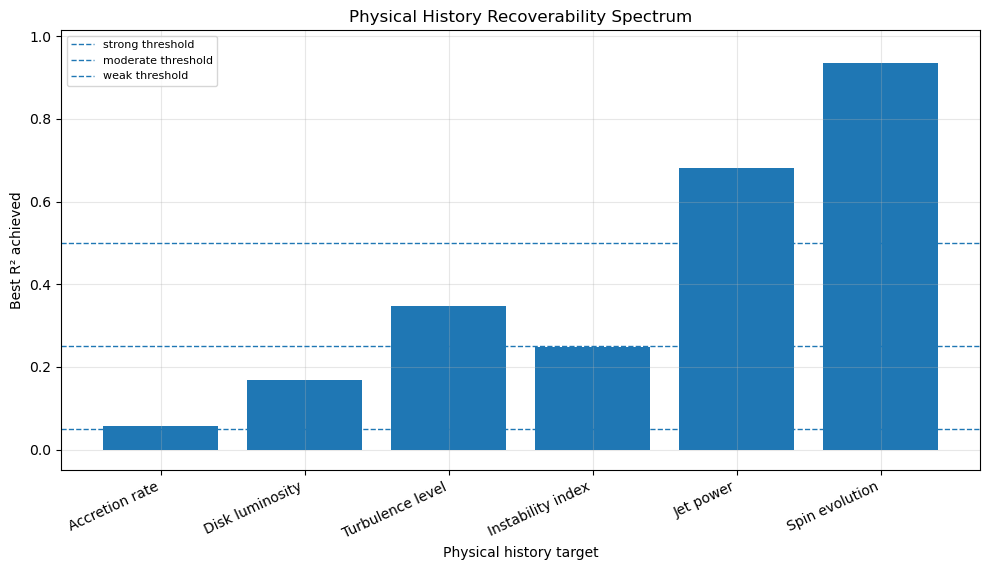

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_1_recoverability_spectrum.png


In [6]:
# ================================================================
# 6. Thesis Figure 1 — Recoverability spectrum
# ================================================================

plot_df = final_recoverability_df.copy()
plot_df["target_label"] = plot_df["target"].astype(str).map(TARGET_LABELS)

plt.figure(figsize=(10, 5.8))
plt.bar(plot_df["target_label"].to_numpy(), plot_df["best_r2"].to_numpy())
plt.axhline(0.50, linestyle="--", linewidth=1, label="strong threshold")
plt.axhline(0.25, linestyle="--", linewidth=1, label="moderate threshold")
plt.axhline(0.05, linestyle="--", linewidth=1, label="weak threshold")
plt.ylabel("Best R² achieved")
plt.xlabel("Physical history target")
plt.title("Physical History Recoverability Spectrum")
plt.xticks(rotation=25, ha="right")
plt.ylim(bottom=min(-0.05, float(plot_df["best_r2"].min()) - 0.05), top=max(1.0, float(plot_df["best_r2"].max()) + 0.08))
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

recoverability_spectrum_path = FINAL_AUDIT_DIR / "figure_1_recoverability_spectrum.png"
plt.savefig(recoverability_spectrum_path, dpi=300)
plt.show()

print("Saved:", recoverability_spectrum_path)

## 7. Thesis Figure 2 — Overall model capacity comparison

This figure answers whether stronger predictors changed the outcome.

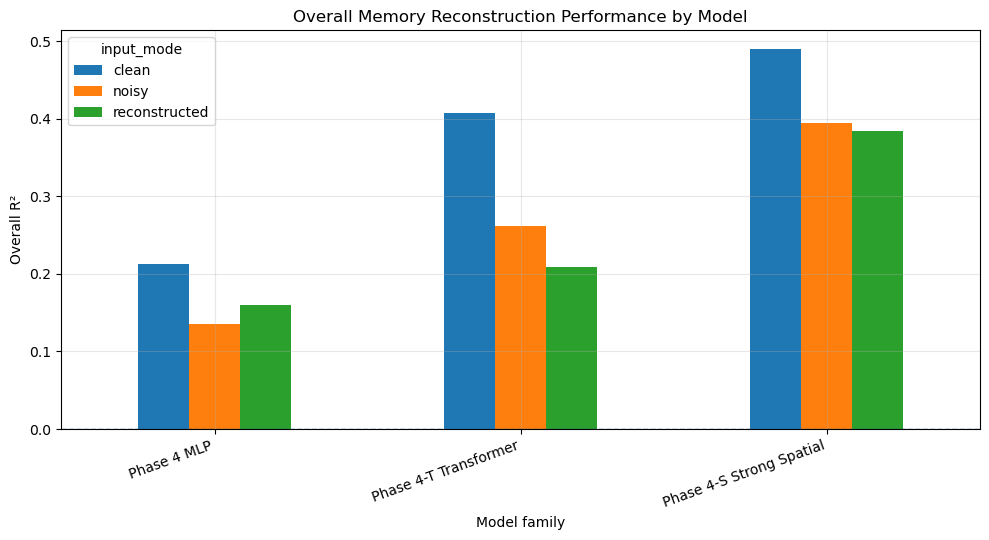

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_2_overall_model_comparison.png


input_mode,clean,noisy,reconstructed
model,,,
Phase 4 MLP,0.212573,0.134942,0.160268
Phase 4-T Transformer,0.407181,0.262474,0.208946
Phase 4-S Strong Spatial,0.489687,0.394160,0.383980


In [7]:
# ================================================================
# 7. Thesis Figure 2 — Overall model comparison
# ================================================================

overall_plot = overall_df.copy()
overall_plot["model"] = pd.Categorical(overall_plot["model"], categories=MODEL_ORDER, ordered=True)
overall_pivot = overall_plot.pivot_table(
    index="model",
    columns="input_mode",
    values="overall_r2",
    aggfunc="first",
    observed=False,
).reindex(MODEL_ORDER).reindex(columns=INPUT_MODES)

ax = overall_pivot.plot(kind="bar", figsize=(10, 5.5))
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_ylabel("Overall R²")
ax.set_xlabel("Model family")
ax.set_title("Overall Memory Reconstruction Performance by Model")
ax.grid(alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

overall_model_path = FINAL_AUDIT_DIR / "figure_2_overall_model_comparison.png"
plt.savefig(overall_model_path, dpi=300)
plt.show()

print("Saved:", overall_model_path)
display(overall_pivot)

## 8. Thesis Figure 3 — Strong Spatial per-target end-to-end performance

The reconstructed mode is the most practical setting because it represents the full pipeline:

```text
noisy observation → U-Net reconstruction → memory predictor
```

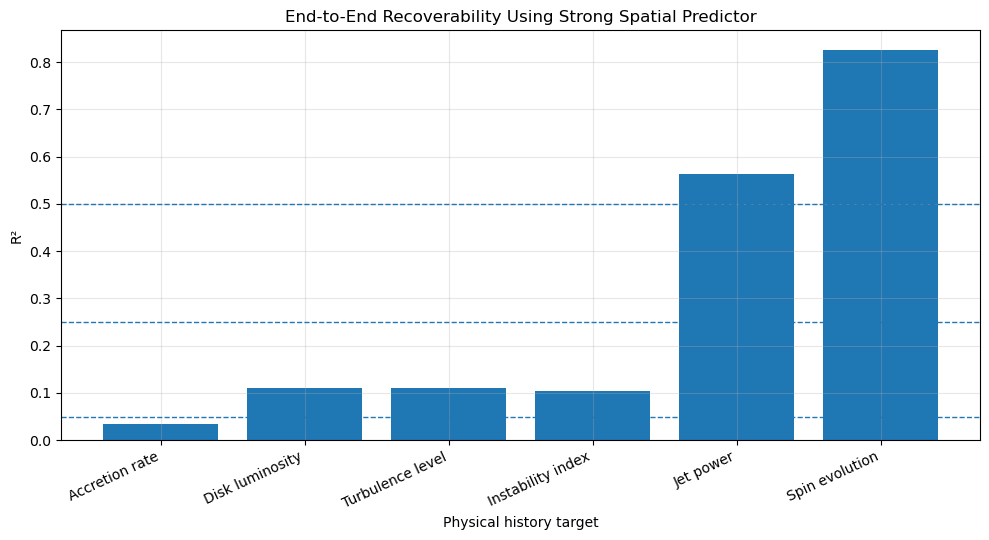

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_3_strong_spatial_reconstructed_per_target.png


,target,mae,corr,r2,recoverability
36,accretion_rate,0.154644,0.247743,0.034353,marginal
39,disk_luminosity,0.117358,0.376886,0.111135,weak
42,turbulence_level,0.189212,0.387671,0.110716,weak
45,instability_index,0.211994,0.334037,0.103149,weak
48,jet_power,0.087106,0.753681,0.562363,strong
51,spin_evolution,0.096848,0.911760,0.825791,strong


In [8]:
# ================================================================
# 8. Thesis Figure 3 — End-to-end Strong Spatial performance
# ================================================================

strong_recon_df = per_target_df[
    (per_target_df["model_key"] == "strong_spatial")
    & (per_target_df["input_mode"] == "reconstructed")
].copy()

strong_recon_df["target"] = pd.Categorical(
    strong_recon_df["target"],
    categories=TARGET_COLUMNS,
    ordered=True,
)
strong_recon_df = strong_recon_df.sort_values("target")
strong_recon_df["target_label"] = strong_recon_df["target"].astype(str).map(TARGET_LABELS)

plt.figure(figsize=(10, 5.5))
plt.bar(strong_recon_df["target_label"].to_numpy(), strong_recon_df["r2"].to_numpy())
plt.axhline(0.50, linestyle="--", linewidth=1)
plt.axhline(0.25, linestyle="--", linewidth=1)
plt.axhline(0.05, linestyle="--", linewidth=1)
plt.ylabel("R²")
plt.xlabel("Physical history target")
plt.title("End-to-End Recoverability Using Strong Spatial Predictor")
plt.xticks(rotation=25, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()

strong_recon_path = FINAL_AUDIT_DIR / "figure_3_strong_spatial_reconstructed_per_target.png"
plt.savefig(strong_recon_path, dpi=300)
plt.show()

print("Saved:", strong_recon_path)
display(strong_recon_df[["target", "mae", "corr", "r2", "recoverability"]])

## 9. Thesis Figure 4 — Model capacity gain over MLP

This figure directly supports the claim that earlier failures were partly caused by predictor capacity, not only by missing information.

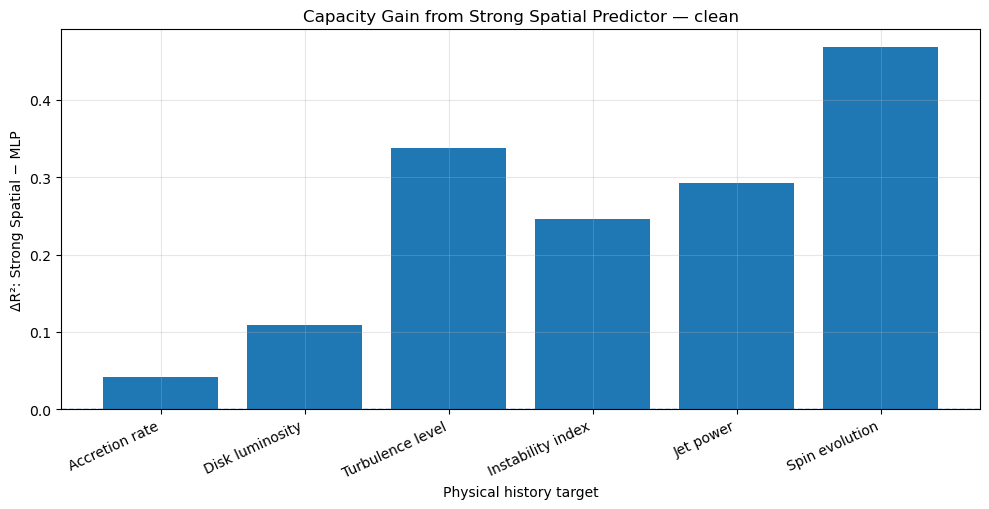

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_4_capacity_gain_over_mlp_clean.png


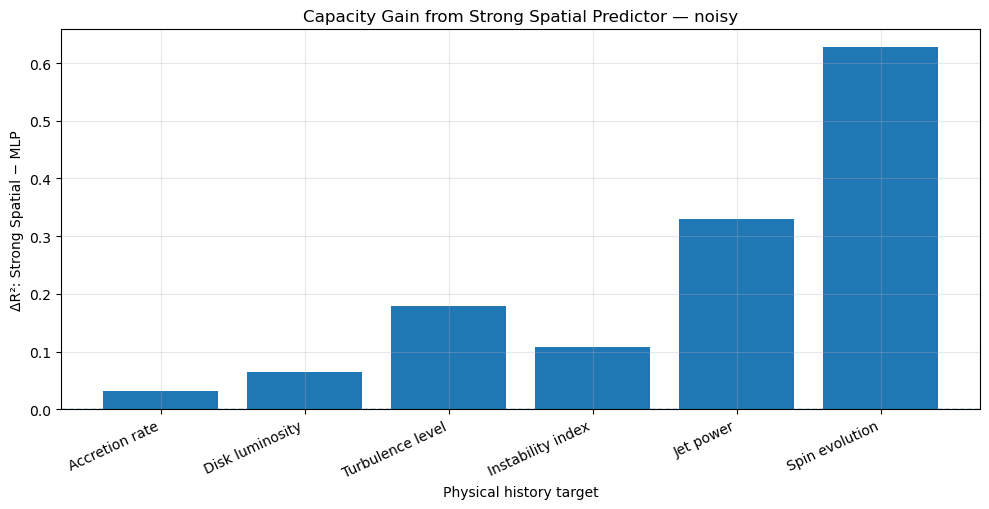

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_4_capacity_gain_over_mlp_noisy.png


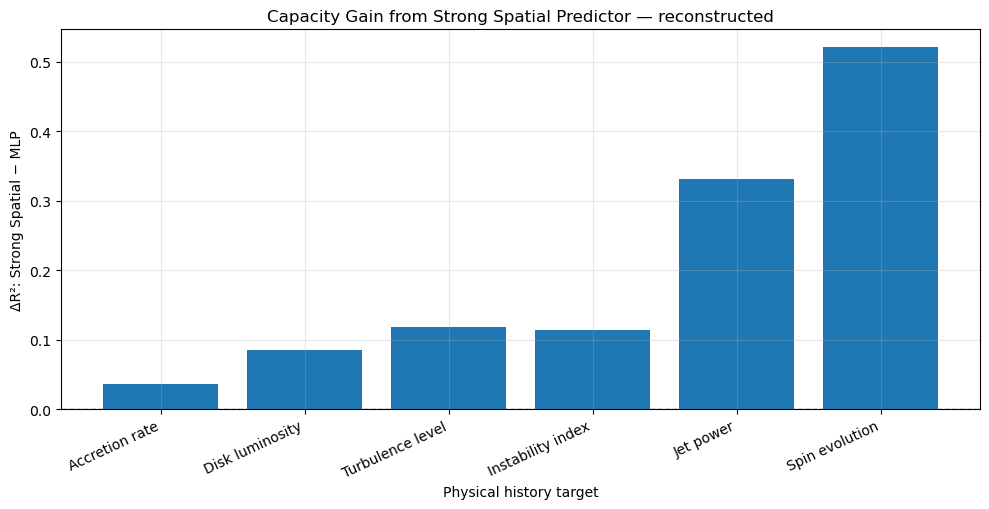

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_4_capacity_gain_over_mlp_reconstructed.png
Saved capacity table: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/final_capacity_gain_analysis.csv


In [9]:
# ================================================================
# 9. Thesis Figure 4 — Capacity gain over MLP
# ================================================================

capacity_plot = capacity_df.copy()
capacity_plot["target"] = pd.Categorical(capacity_plot["target"], categories=TARGET_COLUMNS, ordered=True)

for mode in INPUT_MODES:
    mode_df = capacity_plot[capacity_plot["input_mode"] == mode].copy().sort_values("target")
    mode_df["target_label"] = mode_df["target"].astype(str).map(TARGET_LABELS)

    plt.figure(figsize=(10, 5.2))
    plt.bar(mode_df["target_label"].to_numpy(), mode_df["strong_minus_mlp"].to_numpy())
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.ylabel("ΔR²: Strong Spatial − MLP")
    plt.xlabel("Physical history target")
    plt.title(f"Capacity Gain from Strong Spatial Predictor — {mode}")
    plt.xticks(rotation=25, ha="right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    path = FINAL_AUDIT_DIR / f"figure_4_capacity_gain_over_mlp_{mode}.png"
    plt.savefig(path, dpi=300)
    plt.show()
    print("Saved:", path)

capacity_export_path = FINAL_AUDIT_DIR / "final_capacity_gain_analysis.csv"
capacity_df.to_csv(capacity_export_path, index=False)
print("Saved capacity table:", capacity_export_path)

## 10. Thesis Figure 5 — Input degradation

This figure shows how much recoverability is lost when going from clean images to noisy or reconstructed observations.

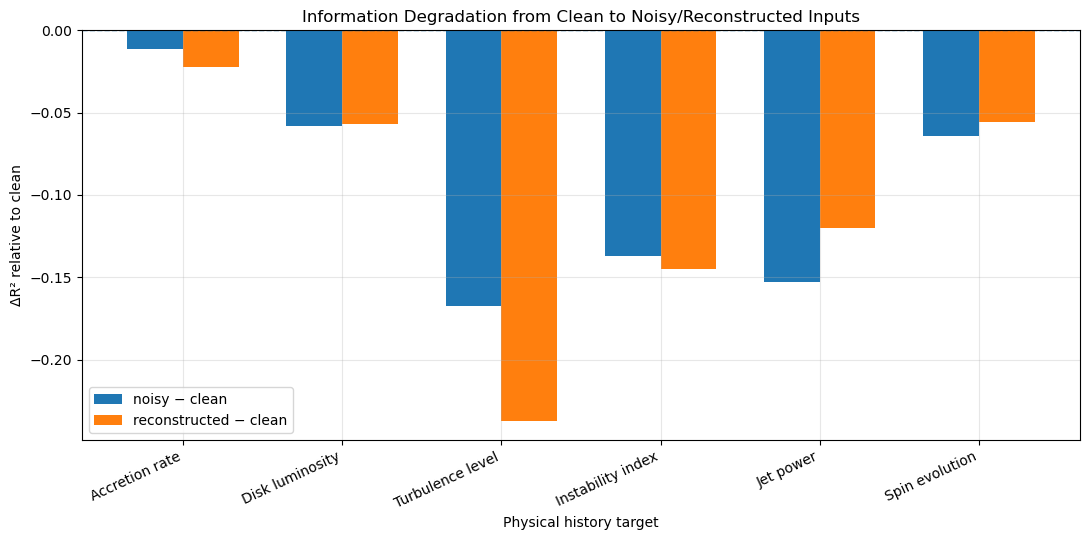

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_5_input_degradation_strong_spatial.png


,model_key,model,target,clean_r2,noisy_r2,reconstructed_r2,noisy_minus_clean,reconstructed_minus_clean,reconstructed_minus_noisy,target_label
0,strong_spatial,Phase 4-S Strong Spatial,accretion_rate,0.056712,0.045482,0.034353,-0.011230,-0.022359,-0.011129,Accretion rate
1,strong_spatial,Phase 4-S Strong Spatial,disk_luminosity,0.167938,0.109557,0.111135,-0.058381,-0.056804,0.001577,Disk luminosity
2,strong_spatial,Phase 4-S Strong Spatial,turbulence_level,0.347873,0.180377,0.110716,-0.167496,-0.237157,-0.069661,Turbulence level
3,strong_spatial,Phase 4-S Strong Spatial,instability_index,0.248135,0.111224,0.103149,-0.136910,-0.144986,-0.008075,Instability index
4,strong_spatial,Phase 4-S Strong Spatial,jet_power,0.682174,0.529112,0.562363,-0.153062,-0.119810,0.033252,Jet power
5,strong_spatial,Phase 4-S Strong Spatial,spin_evolution,0.881378,0.816982,0.825791,-0.064396,-0.055587,0.008809,Spin evolution


In [10]:
# ================================================================
# 10. Thesis Figure 5 — Input degradation for Strong Spatial
# ================================================================

strong_deg = input_degradation_df[input_degradation_df["model_key"] == "strong_spatial"].copy()
strong_deg["target"] = pd.Categorical(strong_deg["target"], categories=TARGET_COLUMNS, ordered=True)
strong_deg = strong_deg.sort_values("target")
strong_deg["target_label"] = strong_deg["target"].astype(str).map(TARGET_LABELS)

x = np.arange(len(strong_deg))
width = 0.35

plt.figure(figsize=(11, 5.5))
plt.bar(x - width/2, strong_deg["noisy_minus_clean"].to_numpy(), width, label="noisy − clean")
plt.bar(x + width/2, strong_deg["reconstructed_minus_clean"].to_numpy(), width, label="reconstructed − clean")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xticks(x, strong_deg["target_label"].to_numpy(), rotation=25, ha="right")
plt.ylabel("ΔR² relative to clean")
plt.xlabel("Physical history target")
plt.title("Information Degradation from Clean to Noisy/Reconstructed Inputs")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

input_degradation_path = FINAL_AUDIT_DIR / "figure_5_input_degradation_strong_spatial.png"
plt.savefig(input_degradation_path, dpi=300)
plt.show()

print("Saved:", input_degradation_path)
display(strong_deg)

## 11. Thesis Figure 6 — Per-target R² heatmap

This compact heatmap is useful in the results chapter because it shows the whole target-by-input-mode landscape for the strongest model.

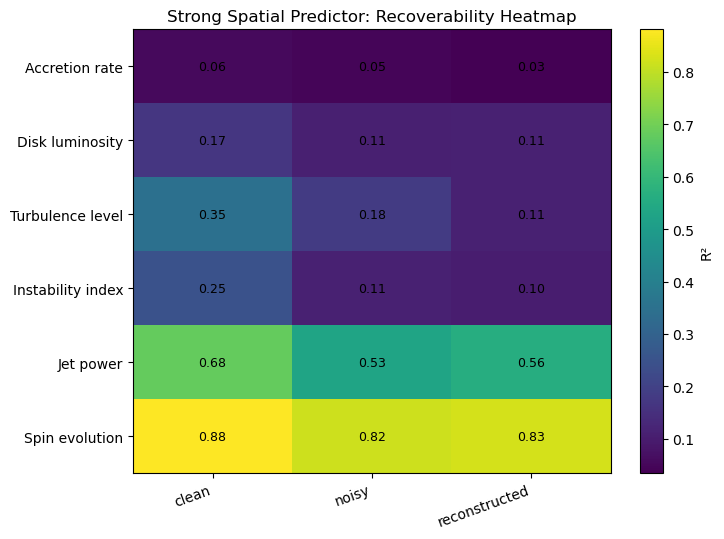

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_6_strong_spatial_r2_heatmap.png


input_mode,clean,noisy,reconstructed
target,,,
accretion_rate,0.056712,0.045482,0.034353
disk_luminosity,0.167938,0.109557,0.111135
turbulence_level,0.347873,0.180377,0.110716
instability_index,0.248135,0.111224,0.103149
jet_power,0.682174,0.529112,0.562363
spin_evolution,0.881378,0.816982,0.825791


In [11]:
# ================================================================
# 11. Thesis Figure 6 — Strong Spatial heatmap
# ================================================================

strong_df = per_target_df[per_target_df["model_key"] == "strong_spatial"].copy()
strong_df["target"] = pd.Categorical(strong_df["target"], categories=TARGET_COLUMNS, ordered=True)

heatmap_pivot = strong_df.pivot_table(
    index="target",
    columns="input_mode",
    values="r2",
    aggfunc="first",
    observed=False,
).reindex(TARGET_COLUMNS).reindex(columns=INPUT_MODES)

heatmap_data = heatmap_pivot.to_numpy(dtype=float)

plt.figure(figsize=(7.5, 5.5))
im = plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(im, label="R²")
plt.xticks(np.arange(len(INPUT_MODES)), INPUT_MODES, rotation=20, ha="right")
plt.yticks(np.arange(len(TARGET_COLUMNS)), [TARGET_LABELS[t] for t in TARGET_COLUMNS])
plt.title("Strong Spatial Predictor: Recoverability Heatmap")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data[i, j]
        if np.isfinite(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
heatmap_path = FINAL_AUDIT_DIR / "figure_6_strong_spatial_r2_heatmap.png"
plt.savefig(heatmap_path, dpi=300)
plt.show()

print("Saved:", heatmap_path)
display(heatmap_pivot)

## 12. Thesis table — compact final results

This section exports compact CSV files that can be directly copied into the thesis/report.

In [12]:
# ================================================================
# 12. Compact thesis tables
# ================================================================

# Compact overall table.
compact_overall = overall_df.pivot_table(
    index="model",
    columns="input_mode",
    values="overall_r2",
    aggfunc="first",
    observed=False,
).reindex(MODEL_ORDER).reindex(columns=INPUT_MODES)

compact_overall_path = FINAL_AUDIT_DIR / "thesis_table_overall_r2_by_model.csv"
compact_overall.to_csv(compact_overall_path)

# Compact strong spatial table.
compact_strong = heatmap_pivot.copy()
compact_strong_path = FINAL_AUDIT_DIR / "thesis_table_strong_spatial_per_target_r2.csv"
compact_strong.to_csv(compact_strong_path)

# Best target table.
thesis_best_path = FINAL_AUDIT_DIR / "thesis_table_final_best_recoverability.csv"
final_recoverability_df.to_csv(thesis_best_path, index=False)

print("Saved:")
print(" ", compact_overall_path)
print(" ", compact_strong_path)
print(" ", thesis_best_path)

display(compact_overall)
display(compact_strong)
display(final_recoverability_df)

Saved:
  /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/thesis_table_overall_r2_by_model.csv
  /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/thesis_table_strong_spatial_per_target_r2.csv
  /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/thesis_table_final_best_recoverability.csv


input_mode,clean,noisy,reconstructed
model,,,
Phase 4 MLP,0.212573,0.134942,0.160268
Phase 4-T Transformer,0.407181,0.262474,0.208946
Phase 4-S Strong Spatial,0.489687,0.394160,0.383980


input_mode,clean,noisy,reconstructed
target,,,
accretion_rate,0.056712,0.045482,0.034353
disk_luminosity,0.167938,0.109557,0.111135
turbulence_level,0.347873,0.180377,0.110716
instability_index,0.248135,0.111224,0.103149
jet_power,0.682174,0.529112,0.562363
spin_evolution,0.881378,0.816982,0.825791


,target,target_label,best_model,best_input_mode,best_mae,best_corr,best_r2,recoverability_class,thesis_verdict
0,accretion_rate,Accretion rate,Phase 4-S Strong Spatial,clean,0.153387,0.264519,0.056712,weak,Weakly recoverable
1,disk_luminosity,Disk luminosity,Phase 4-S Strong Spatial,clean,0.115401,0.424098,0.167938,weak,Weakly recoverable
2,turbulence_level,Turbulence level,Phase 4-S Strong Spatial,clean,0.156576,0.595258,0.347873,moderate,Partially recoverable
3,instability_index,Instability index,Phase 4-S Strong Spatial,clean,0.191345,0.499267,0.248135,weak,Weakly recoverable
4,jet_power,Jet power,Phase 4-S Strong Spatial,clean,0.071915,0.826782,0.682174,strong,Recoverable
5,spin_evolution,Spin evolution,Phase 4-T Transformer,clean,0.058154,0.969277,0.934600,strong,Recoverable


## 13. Final written synthesis

This cell writes a thesis-ready conclusion based on the actual tables above.

In [13]:
# ================================================================
# 13. Final written synthesis
# ================================================================

best_overall = overall_df.dropna(subset=["overall_r2"]).sort_values("overall_r2", ascending=False).iloc[0]

strong_recon_overall = overall_df[
    (overall_df["model_key"] == "strong_spatial")
    & (overall_df["input_mode"] == "reconstructed")
]

if len(strong_recon_overall):
    strong_recon_row = strong_recon_overall.iloc[0]
else:
    strong_recon_row = None

recoverable = final_recoverability_df[
    final_recoverability_df["thesis_verdict"].isin(["Recoverable", "Partially recoverable"])
]
weak_or_below = final_recoverability_df[
    ~final_recoverability_df["thesis_verdict"].isin(["Recoverable", "Partially recoverable"])
]

lines = []
lines.append("Final Audit — Black Hole Memory Reconstruction")
lines.append("=" * 55)
lines.append("")
lines.append(f"Dataset: {DATASET_DIR}")
lines.append(f"Comparison source: {COMPARISON_DIR}")
lines.append(f"Final audit output: {FINAL_AUDIT_DIR}")
lines.append("")
lines.append("Best overall run:")
lines.append(f"  Model      : {best_overall['model']}")
lines.append(f"  Input mode : {best_overall['input_mode']}")
lines.append(f"  MAE        : {best_overall['overall_mae']:.5f}")
lines.append(f"  Corr       : {best_overall['overall_corr']:.5f}")
lines.append(f"  R2         : {best_overall['overall_r2']:.5f}")
lines.append("")

if strong_recon_row is not None:
    lines.append("Most practical end-to-end setting:")
    lines.append("  Model      : Phase 4-S Strong Spatial")
    lines.append("  Input mode : reconstructed")
    lines.append(f"  MAE        : {strong_recon_row['overall_mae']:.5f}")
    lines.append(f"  Corr       : {strong_recon_row['overall_corr']:.5f}")
    lines.append(f"  R2         : {strong_recon_row['overall_r2']:.5f}")
    lines.append("")

lines.append("Final target-level recoverability:")
for _, row in final_recoverability_df.iterrows():
    lines.append(
        f"  - {row['target_label']}: {row['thesis_verdict']} "
        f"(best R2={row['best_r2']:.5f}, corr={row['best_corr']:.5f}, "
        f"model={row['best_model']}, input={row['best_input_mode']})"
    )
lines.append("")

lines.append("Scientific interpretation:")
lines.append("  The final comparison shows that memory reconstruction from a single static black-hole image is target-dependent.")
lines.append("  Stronger spatial predictors substantially improve recoverability over pooled MLP and transformer baselines, especially for morphology-linked targets.")
lines.append("  This demonstrates that earlier failures were not purely caused by missing information in the image; they were partly caused by insufficient spatial feature extraction.")
lines.append("  However, not all histories become strongly recoverable. The remaining weak targets indicate an identifiability limit for single-image historical inference.")
lines.append("")

lines.append("Recommended thesis claim:")
lines.append("  Static black-hole observations can encode partial memory of previous physical states, but the recoverability is uneven across physical variables.")
lines.append("  Spin evolution and jet power are the most recoverable histories in the current synthetic universe.")
lines.append("  Turbulence and instability are partially or weakly recoverable depending on input quality and predictor capacity.")
lines.append("  Accretion-rate history remains the weakest target under the final morphology-heavy dataset, suggesting that its current visual encoding is insufficient or confounded by other brightness-related variables.")
lines.append("")

lines.append("Final decision:")
lines.append("  Stop generating new dataset phases for now. Use this audit as the final model-capacity and recoverability result.")
lines.append("  The next work should be thesis writing, figure polishing, and possibly a small validation appendix, not another generator iteration.")

summary_text = "\n".join(lines)
summary_path = FINAL_AUDIT_DIR / "final_audit_thesis_synthesis.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved:", summary_path)

Final Audit — Black Hole Memory Reconstruction

Dataset: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology
Comparison source: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final
Final audit output: /home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures

Best overall run:
  Model      : Phase 4-S Strong Spatial
  Input mode : clean
  MAE        : 0.12560
  Corr       : 0.70162
  R2         : 0.48969

Most practical end-to-end setting:
  Model      : Phase 4-S Strong Spatial
  Input mode : reconstructed
  MAE        : 0.14286
  Corr       : 0.62492
  R2         : 0.38398

Final target-level recoverability:
  - Accretion rate: Weakly recoverable (best R2=0.05671, corr=0.26452, model=Phase 4-S Strong Spatial, input=clean)
  - Disk luminosity: Weakly recoverable (best R2=0.16794, corr=0.42410, model=Phase 4-S Strong Spatial, input=clean)
  - Turbulence level: Partially recoverable (best R2=0.34787, corr=0.59

## 14. Export final asset manifest

This manifest lists the key files produced by the final audit.

In [14]:
# ================================================================
# 14. Export final asset manifest
# ================================================================

asset_paths = [
    final_recoverability_path,
    recoverability_spectrum_path,
    overall_model_path,
    strong_recon_path,
    input_degradation_path,
    heatmap_path,
    compact_overall_path,
    compact_strong_path,
    thesis_best_path,
    summary_path,
]

# Include all capacity gain figures.
asset_paths.extend(sorted(FINAL_AUDIT_DIR.glob("figure_4_capacity_gain_over_mlp_*.png")))

manifest = {
    "project_root": str(PROJECT_ROOT),
    "dataset_dir": str(DATASET_DIR),
    "comparison_dir": str(COMPARISON_DIR),
    "final_audit_dir": str(FINAL_AUDIT_DIR),
    "assets": [str(p) for p in asset_paths if Path(p).exists()],
}

manifest_path = FINAL_AUDIT_DIR / "final_audit_asset_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))
print("Saved:", manifest_path)

{
  "project_root": "/home/marwa/files/phase1_blackhole_generator",
  "dataset_dir": "/home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology",
  "comparison_dir": "/home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final",
  "final_audit_dir": "/home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures",
  "assets": [
    "/home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/final_recoverability_table.csv",
    "/home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_1_recoverability_spectrum.png",
    "/home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_2_overall_model_comparison.png",
    "/home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_3_strong_spatial_reconstructed_per_target.png",
    "/home/marwa/files/phase1_blackhole_generator/outputs/final_audit_thesis_figures/figure_5_input_deg

# Final note

This notebook is the endpoint of the current experimental loop. The defensible outcome is not “perfect memory reconstruction.” The defensible outcome is:

> A single static black-hole image contains uneven but measurable recoverability of physical histories. The recoverability depends strongly on the target variable, input quality, and predictor architecture.

That is the clean thesis result.